In [228]:
import torch
import numpy as np
import random
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from torchvision import transforms

from train import CLASS_MAPPING, NUM_CLASSES

In [229]:
MODEL_PATH = "runs/best_model.pth"
TEST_RGB_DIR = "/run/media/wolverine/Windows/ML dataset/Offroad_Segmentation_testImages/test/rgb"
TEST_SEG_DIR = "/run/media/wolverine/Windows/ML dataset/Offroad_Segmentation_testImages/test/seg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [230]:
def get_model(num_classes):
    return smp.Unet(
        encoder_name="resnet50",
        encoder_weights=None,
        in_channels=3,
        classes=num_classes,
    )

model = get_model(NUM_CLASSES).to(device)

checkpoint = torch.load(MODEL_PATH, map_location=device,weights_only=False)
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("Model loaded.")

Model loaded.


In [231]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
def create_color_map():
    return np.array([
        [0, 0, 0],          # Background
        [34,139,34],        # Trees
        [50,205,50],        # Lush Bushes
        [210,180,140],      # Dry Grass
        [139,69,19],        # Dry Bushes
        [0
        , 0, 255],        # Ground Clutter (Walkable Path - RED)
        [255,192,203],      # Flowers
        [101,67,33],        # Logs
        [128,128,128],      # Rocks
        [135,206,235],      # Sky
        [186, 85, 211],     # Small Animal (Purple)
        [0, 255, 255],      # Miscellaneous (Cyan)
    ], dtype=np.uint8)
color_map = create_color_map()

def mask_to_rgb(mask):
    rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for cls in range(NUM_CLASSES):
        rgb[mask == cls] = color_map[cls]
    return rgb

In [ ]:
image_files = sorted([
    f for f in os.listdir(TEST_RGB_DIR)
    if f.endswith((".png", ".jpg", ".jpeg"))
])

random_file = random.choice(image_files)
print("Selected:", random_file)

img_path = Path(TEST_RGB_DIR) / random_file
mask_path = Path(TEST_SEG_DIR) / random_file
img_path="./sample3.jpeg"
image_pil = Image.open(img_path).convert("RGB")
mask_pil = Image.open(mask_path).resize((256, 256), Image.NEAREST)

image_tensor = transform(image_pil).unsqueeze(0).to(device)


Selected: 0000404.png


In [234]:
with torch.no_grad():
    output = model(image_tensor)
    pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

# Ground truth processing
gt_array = np.array(mask_pil)
gt_mask = np.zeros_like(gt_array)

for original_class, new_class in CLASS_MAPPING.items():
    gt_mask[gt_array == original_class] = new_class

In [235]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

input_image = image_tensor.squeeze(0).cpu().permute(1,2,0).numpy()
input_image = std * input_image + mean
input_image = np.clip(input_image, 0, 1)

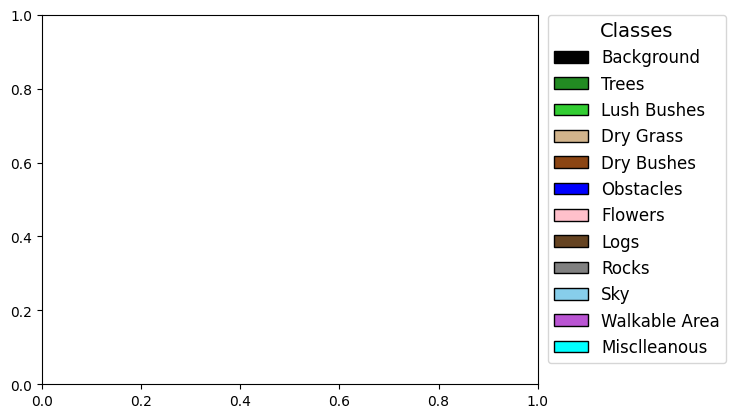

In [236]:
from matplotlib.patches import Patch

class_names = [
    "Background",
    "Trees",
    "Lush Bushes",
    "Dry Grass",
    "Dry Bushes",
    "Obstacles",
    "Flowers",
    "Logs",
    "Rocks",
    "Sky",
    "Walkable Area",
    "Misclleanous"
]

from matplotlib.patches import Patch

color_map = create_color_map()

legend_elements = [
    Patch(
        facecolor=color_map[i] / 255.0,
        edgecolor='black',
        label=class_names[i]
    )
    for i in range(len(class_names))
]

plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=12,          # Bigger text
    title="Classes",
    title_fontsize=14,
    frameon=True
)

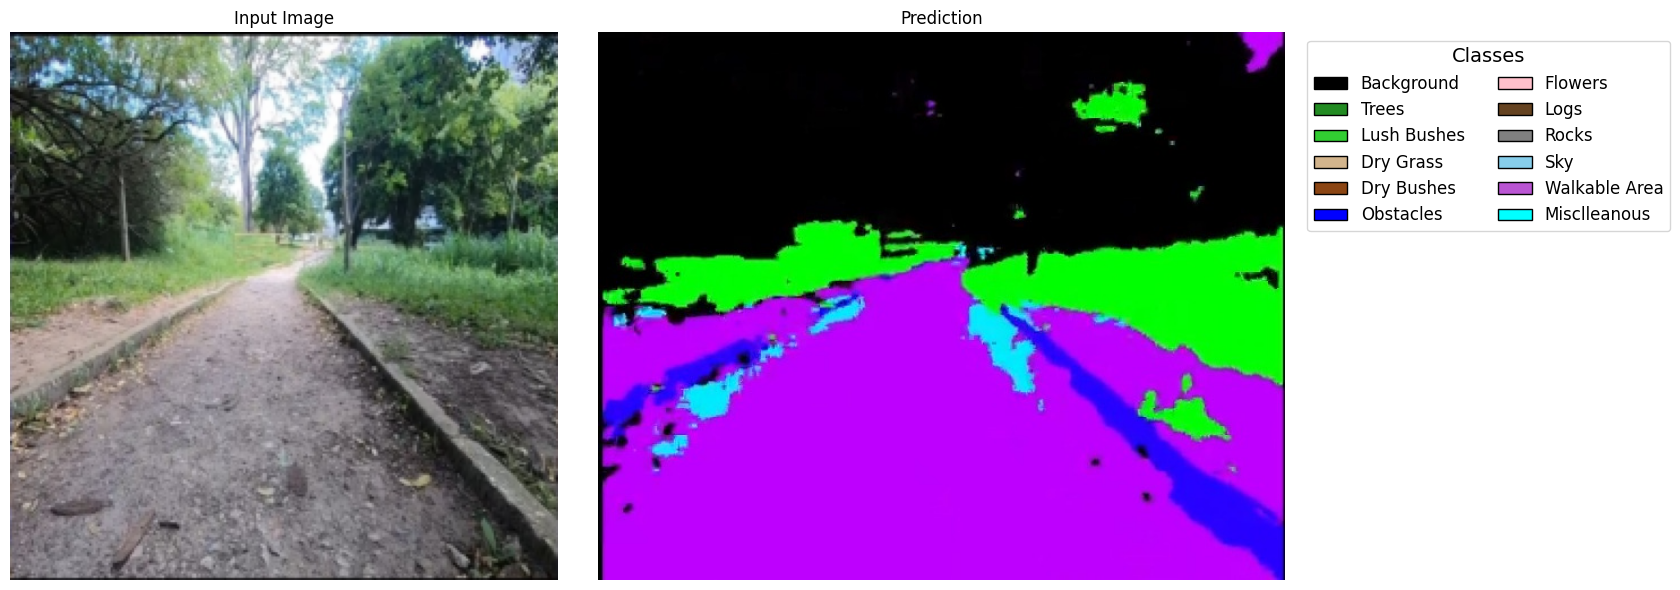

In [ ]:
pred_rgb = mask_to_rgb(pred_mask)
gt_rgb = mask_to_rgb(gt_mask)
# pred_rgb="./output.jpeg"
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(input_image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt_rgb)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
gt_rgb = mask_to_rgb(gt_mask)
pred_rgb = np.array(Image.open("./output.jpeg"))
plt.imshow(pred_rgb)
plt.title("Prediction")
plt.axis("off")

# Add legend outside the figure
plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=12,
    title="Classes",
    title_fontsize=14,
    frameon=True,
    ncol=2
)
plt.tight_layout()
plt.show()